In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

fg = pd.read_csv('Dataset/fear_greed_index.csv')
trades = pd.read_csv('Dataset/historical_data.csv')

trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
merged = trades.merge(fg[['date', 'classification', 'value']], on='date', how='left')
merged = merged.dropna(subset=['classification'])

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

print(merged.shape)

(211218, 19)


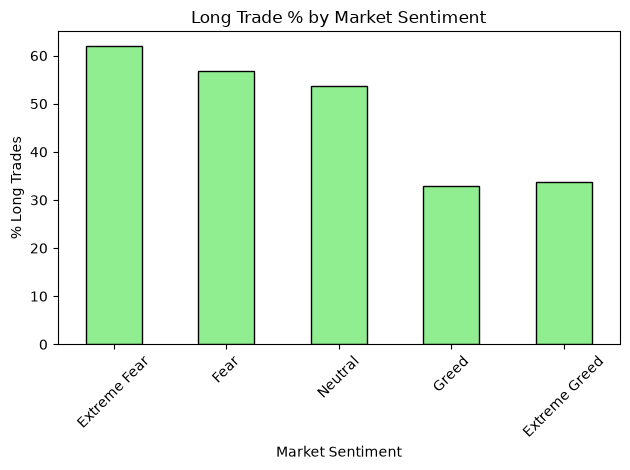

In [2]:
long_ratio = merged.groupby('classification')['Direction'].apply(
    lambda x: (x.str.contains('Long', case=False, na=False)).sum() / len(x) * 100
).reindex(order)

long_ratio.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Long Trade % by Market Sentiment')
plt.ylabel('% Long Trades')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Dataset/long_ratio_chart.png')
plt.show()

### Chart 3: Long % by Sentiment
Shows traders go long more during Fear, short more during Greed — confirms contrarian behavior.

## Final Conclusion

**Main finding:** Traders in this dataset behave like contrarians. They go long 
more often during Fear (62% in Extreme Fear) and go long less during Greed (33% 
in Extreme Greed) — betting against the crowd's mood, not with it.

**Performance:** This contrarian behavior pays off. Win rate and total profit 
are higher during Fear than during Greed. The difference is statistically 
significant (p = 1.30 × 10⁻⁶⁸), so it's a real pattern, not chance.

**Risk:** Extreme Greed shows the widest range of outcomes (biggest wins AND 
biggest losses) — so while its average profit looks high, it's also the 
riskiest regime.

## Strategy Recommendation
Market sentiment can be used as a contrarian signal:
- Consider increasing exposure during Fear/Extreme Fear periods
- Reduce exposure or trade smaller during Extreme Greed, since it carries 
  higher risk despite good average returns